# Week 4 Exercise: Stemming, lemmatization, and word cloud


In [1]:
#!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 44.0 MB/s  0:00:00eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
import os
from glob import glob
import nltk
import spacy
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import bz2
import pickle
import urllib.request
import tarfile
import re

In [3]:
# Download required resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nlp = spacy.load("en_core_web_sm")  # Load spaCy model

[nltk_data] Downloading package punkt to /Users/anne/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/anne/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/anne/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### **1. Load the dataset**

In [4]:

# 1. Load or download the IMDB dataset

filename = "reviewdata.pickle.bz2"

if os.path.exists(filename):
    print(f"Using cached file {filename}")
    with bz2.BZ2File(filename, "r") as zipfile:
        data = pickle.load(zipfile)
    text_train, text_test, y_train, y_test = data

else:
    url = "https://cssbook.net/d/aclImdb_v1.tar.gz"
    print(f"Downloading from {url}")
    fn, _headers = urllib.request.urlretrieve(url, filename=None)
    t = tarfile.open(fn, mode="r:gz")

    text_train, text_test = [], []
    y_train, y_test = [], []

    for f in t.getmembers():
        # match paths like: aclImdb/train/pos/xxx.txt or aclImdb/test/neg/yyy.txt
        m = re.match(r"aclImdb/(\w+)/(pos|neg)/", f.name)
        if not m:
            # skip folder names, other categories, etc.
            continue
        dataset, label = m.groups()
        text = t.extractfile(f).read().decode("utf-8")

        if dataset == "train":
            text_train.append(text)
            y_train.append(label)
        elif dataset == "test":
            text_test.append(text)
            y_test.append(label)

    data = (text_train, text_test, y_train, y_test)
    print(f"Saving to {filename}")
    with bz2.BZ2File(filename, "w") as zipfile:
        pickle.dump(data, zipfile)

print(f"Loaded {len(text_train)} train reviews and {len(text_test)} test reviews.")


# 2. Use the TRAIN data as your "documents"


# All training reviews:
documents = text_train
labels = y_train  # "pos"/"neg"

print(f"Using {len(documents)} documents from IMDB training set.")

# Optional: if you want a smaller subset, e.g. first 1000:
# documents = text_train[:1000]
# labels = y_train[:1000]
# print(f"Using subset of {len(documents)} documents.")

# Quick sanity check
print("Example document:\n")
print(documents[0][:500])  # print first 500 characters of first review
print("\nLabel:", labels[0])

Using cached file reviewdata.pickle.bz2
Loaded 25000 train reviews and 25000 test reviews.
Using 25000 documents from IMDB training set.
Example document:

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent

Label: neg


In [5]:
documents = documents[:100] ### Note that things slow down if you take a larger sample, so for practicing try it out on a small sample

before we can continue to stemming and lemmaitizaton, we should apply tokenization

In [6]:
# Step 2: Tokenization
print("\n### Tokenization ###")
tokens = [word_tokenize(doc.lower()) for doc in documents]  # Convert to lowercase and tokenize
print("First 20 tokens from the first document:", tokens[0][:20])


### Step 3: Stopword Removal ###
print("\n### Stopword Removal ###")
stop_words = set(stopwords.words('english'))
filtered_tokens = [[word for word in doc if word.isalnum() and word not in stop_words] for doc in tokens]
print("Tokens after removing stopwords (first document):", filtered_tokens[0][:20])


### Tokenization ###
First 20 tokens from the first document: ['i', 'rented', 'i', 'am', 'curious-yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was']

### Stopword Removal ###
Tokens after removing stopwords (first document): ['rented', 'video', 'store', 'controversy', 'surrounded', 'first', 'released', 'also', 'heard', 'first', 'seized', 'customs', 'ever', 'tried', 'enter', 'country', 'therefore', 'fan', 'films', 'considered']


### **2. Apply stemming and lemmatization**

In [7]:
### Step 4: Stemming and Lemmatization ###
print("\n### Stemming and Lemmatization ###")
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

stemmed_words = [[stemmer.stem(word) for word in doc] for doc in filtered_tokens]
lemmatized_words_nltk = [[lemmatizer.lemmatize(word, pos='v') for word in doc] for doc in filtered_tokens]

# Using spaCy for lemmatization
lemmatized_words_spacy = []
for doc in filtered_tokens:
    spacy_doc = nlp(" ".join(doc))
    lemmatized_words_spacy.append([token.lemma_ for token in spacy_doc])
    
print("First 20 stemmed words (PorterStemmer, first document):", stemmed_words[0][:20])
print("First 20 lemmatized words (NLTK, first document):", lemmatized_words_nltk[0][:20])
print("First 20 lemmatized words (spaCy, first document):", lemmatized_words_spacy[0][:20])


### Stemming and Lemmatization ###
First 20 stemmed words (PorterStemmer, first document): ['rent', 'video', 'store', 'controversi', 'surround', 'first', 'releas', 'also', 'heard', 'first', 'seiz', 'custom', 'ever', 'tri', 'enter', 'countri', 'therefor', 'fan', 'film', 'consid']
First 20 lemmatized words (NLTK, first document): ['rent', 'video', 'store', 'controversy', 'surround', 'first', 'release', 'also', 'hear', 'first', 'seize', 'customs', 'ever', 'try', 'enter', 'country', 'therefore', 'fan', 'film', 'consider']
First 20 lemmatized words (spaCy, first document): ['rent', 'video', 'store', 'controversy', 'surround', 'first', 'release', 'also', 'hear', 'first', 'seize', 'custom', 'ever', 'try', 'enter', 'country', 'therefore', 'fan', 'film', 'consider']


### 3. Generate word cloud


### Generating Word Cloud ###


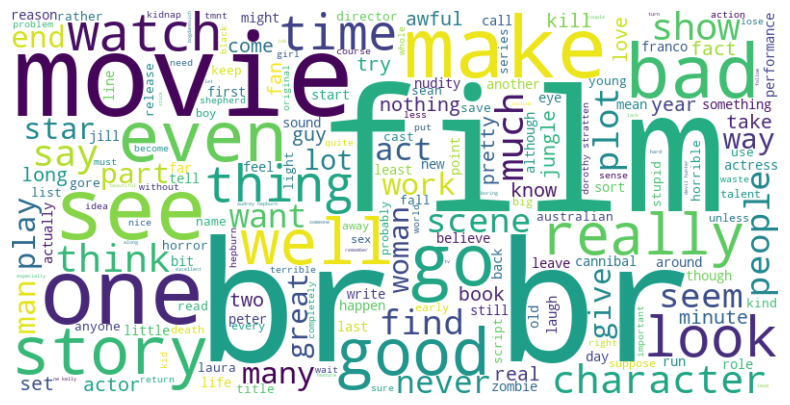

In [8]:
print("\n### Generating Word Cloud ###")
all_lemmatized_text = " ".join([" ".join(doc) for doc in lemmatized_words_spacy])

if all_lemmatized_text:
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_lemmatized_text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()
else:
    print("No words available to generate a word cloud.")